In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('savings_dataset_cleaned.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print("Data loaded successfully! Total rows:", len(df))

Data loaded successfully! Total rows: 412


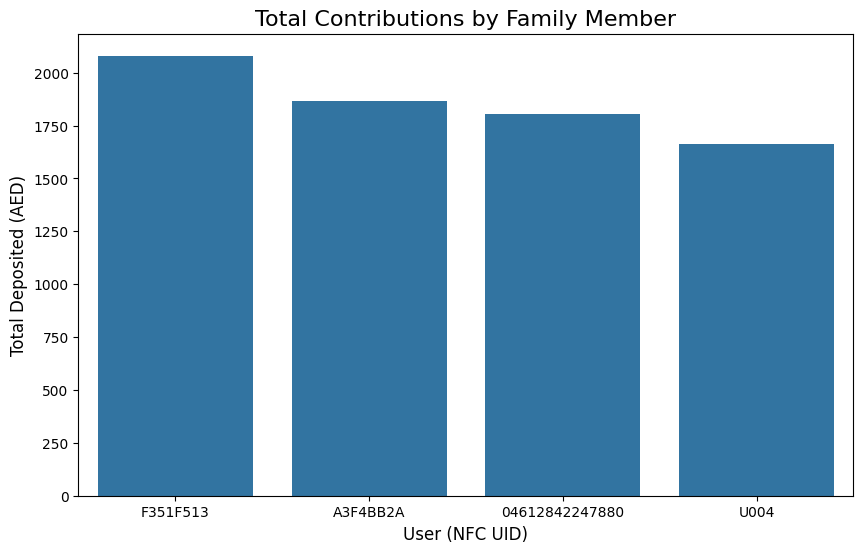

In [3]:
# BAR CHART FOR WHO SAVED MORE
plt.figure(figsize=(10, 6))

# Group by user and sum up their total deposits
user_totals = df.groupby('NFC_UID')['Deposit_Amount'].sum().sort_values(ascending=False)

# Create a bar chart
sns.barplot(x=user_totals.index, y=user_totals.values)

plt.title("Total Contributions by Family Member", fontsize=16)
plt.xlabel("User (NFC UID)", fontsize=12)
plt.ylabel("Total Deposited (AED)", fontsize=12)

plt.show()

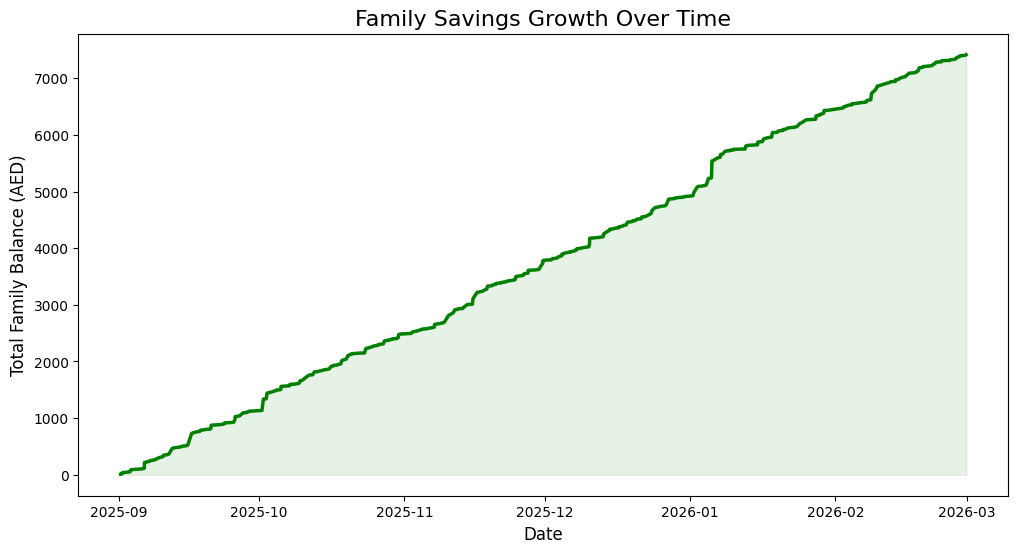

In [4]:
# Overall Family Savings Progress
plt.figure(figsize=(12, 6))

# sort time 
df = df.sort_values('Timestamp')

# Calculate the total of the family
df['Family_Running_Total'] = df['Deposit_Amount'].cumsum()

plt.plot(df['Timestamp'], df['Family_Running_Total'], color='green', linewidth=2.5)

plt.fill_between(df['Timestamp'], df['Family_Running_Total'], color='green', alpha=0.1)

plt.title("Family Savings Growth Over Time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Family Balance (AED)", fontsize=12)

plt.show()

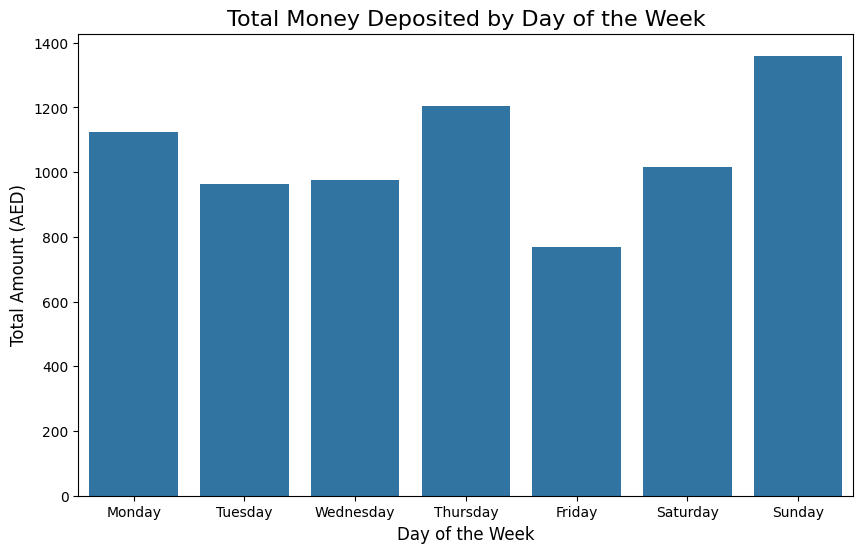

In [5]:
# BAR CHART FOR WHICH DAY WAS SAVED MORE
plt.figure(figsize=(10, 6))


# Extract the day of the week
df['Day_Name'] = df['Timestamp'].dt.day_name()

# Order the days properly
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Sum deposits per day
day_totals = df.groupby('Day_Name')['Deposit_Amount'].sum().reindex(days_order)

# Plotting
sns.barplot(x=day_totals.index, y=day_totals.values)

plt.title("Total Money Deposited by Day of the Week", fontsize=16)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Total Amount (AED)", fontsize=12)

plt.show()

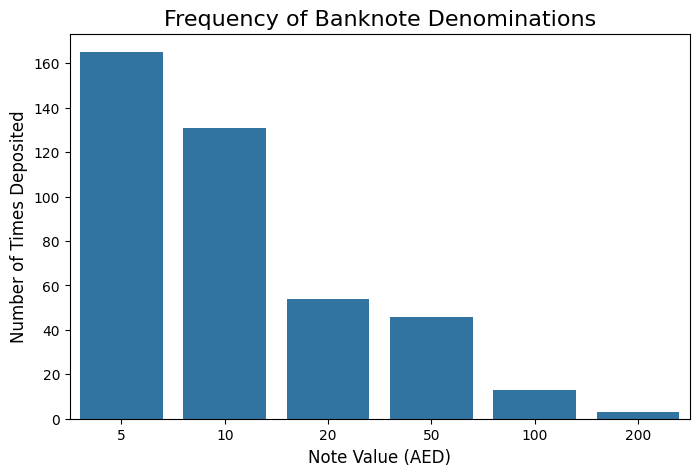

In [6]:
# CELL 5: Most Common Banknotes Used
plt.figure(figsize=(8, 5))

# Count how many times each specific note was inserted
note_counts = df['Deposit_Amount'].value_counts().sort_index()

sns.barplot(x=note_counts.index, y=note_counts.values)

plt.title("Frequency of Banknote Denominations", fontsize=16)
plt.xlabel("Note Value (AED)", fontsize=12)
plt.ylabel("Number of Times Deposited", fontsize=12)

plt.show()

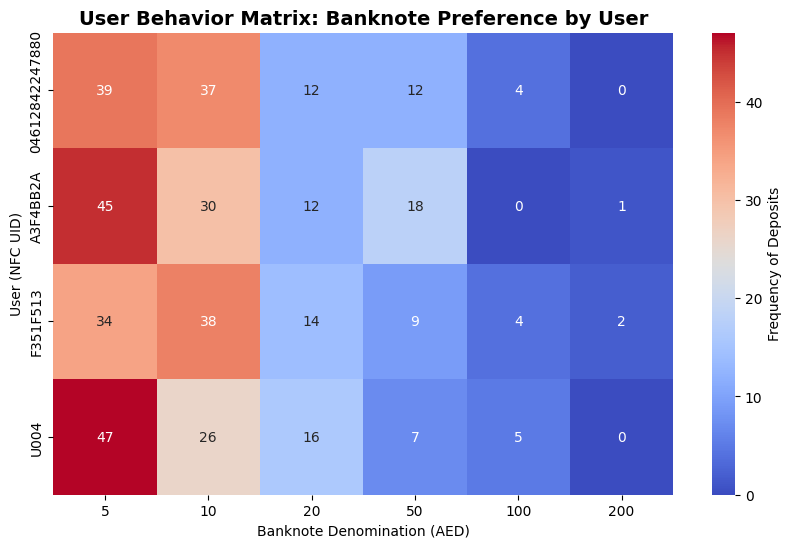

In [7]:
# User Behavior Matrix to Identify Their Preferred Note
plt.figure(figsize=(10, 6))

user_note_matrix = pd.crosstab(df['NFC_UID'], df['Deposit_Amount'])

# Generate a heatmap 
sns.heatmap(user_note_matrix, annot=True, cmap='coolwarm', fmt='d', cbar_kws={'label': 'Frequency of Deposits'})

plt.title('User Behavior Matrix: Banknote Preference by User', fontsize=14, fontweight='bold')
plt.xlabel('Banknote Denomination (AED)')
plt.ylabel('User (NFC UID)')

plt.show()